# Bike Sharing in the Bay Area

We end this chapter by using many of the pandas operations we have learned to examine a large dataset. We will also introduce mapping and visualization tools available in the Python data science ecosystem.

The Bay Area Bike Share service published a dataset describing every bicycle rental from September 2014 to August 2015 in their system. There were 354,152 rentals in all. The columns are:

- An ID for the rental
- Duration of the rental, in seconds
- Start date
- Name of the Start Station and code for Start Terminal
- Name of the End Station and code for End Terminal
- A serial number for the bike
- Subscriber type and zip code

In [1]:
import pandas as pd
%matplotlib inline
path_data = "../../../assets/data/"
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import math
from scipy import stats
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
trips = pd.read_csv(path_data + 'trip.csv')
trips

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
0,913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
1,913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
2,913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107
3,913454,409,8/31/2015 23:10,San Jose City Hall,10,8/31/2015 23:17,San Salvador at 1st,8,68,Subscriber,95113
4,913453,789,8/31/2015 23:09,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,487,Customer,9069
...,...,...,...,...,...,...,...,...,...,...,...
354147,432951,619,9/1/2014 4:21,Powell Street BART,39,9/1/2014 4:32,Townsend at 7th,65,335,Subscriber,94118
354148,432950,6712,9/1/2014 3:16,Harry Bridges Plaza (Ferry Building),50,9/1/2014 5:08,San Francisco Caltrain (Townsend at 4th),70,259,Customer,44100
354149,432949,538,9/1/2014 0:05,South Van Ness at Market,66,9/1/2014 0:14,5th at Howard,57,466,Customer,32
354150,432948,568,9/1/2014 0:05,South Van Ness at Market,66,9/1/2014 0:15,5th at Howard,57,461,Customer,32


We'll focus only on the *free trips*, which are trips that last less than 1800 seconds (half an hour). There is a charge for longer trips.

The histogram below shows that most trips took around 10 minutes (600 seconds) or so.

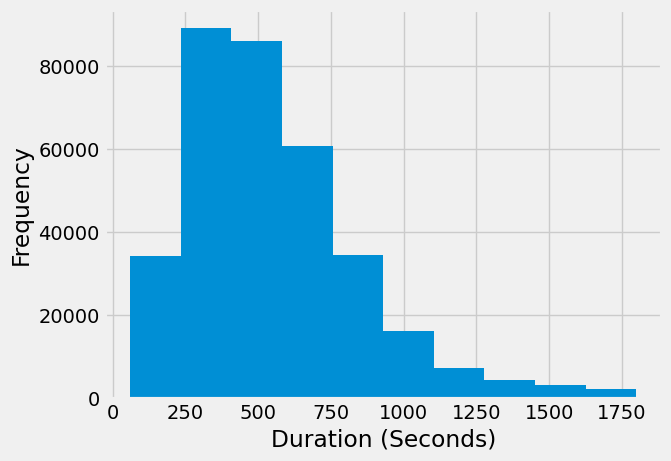

In [3]:
commute = trips[trips['Duration'] < 1800]
commute['Duration'].plot.hist(bins=10)
plt.xlabel('Duration (Seconds)')
plt.show()

We can get more detail by specifying a larger number of bins.

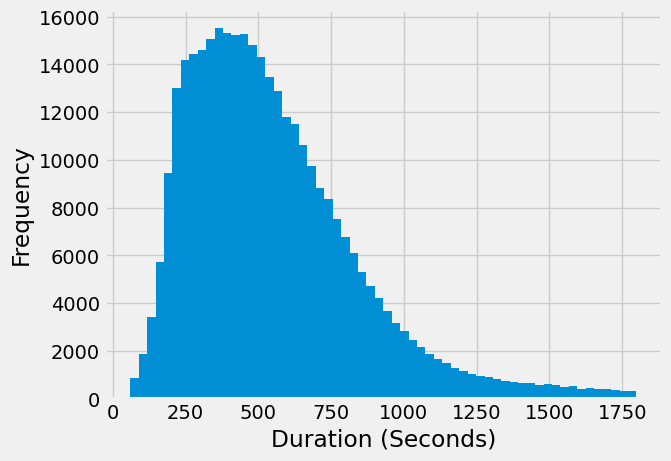

In [4]:
commute['Duration'].plot.hist(bins=60)
plt.xlabel('Duration (Seconds)')
plt.show()

## Exploring the Data with `groupby` and Pivot Tables

We can use `groupby` to identify the most highly used start station.

In [5]:
starts = commute.groupby('Start Station').size().reset_index(name='count').sort_values('count', ascending=False)
starts

,Start Station,count
49,San Francisco Caltrain (Townsend at 4th),25858
50,San Francisco Caltrain 2 (330 Townsend),21523
23,Harry Bridges Plaza (Ferry Building),15543
65,Temporary Transbay Terminal (Howard at Beale),14298
2,2nd at Townsend,13674
...,...,...
31,Mezes Park,189
41,Redwood City Medical Center,139
55,San Mateo County Center,108
42,Redwood City Public Library,101


The largest number of trips started at the Caltrain Station on Townsend and 4th in San Francisco.

The `groupby` method can also be used to classify rentals by both Start Station and End Station.

In [6]:
commute.groupby(['Start Station','End Station']).size().reset_index(name='count')

,Start Station,End Station,count
0,2nd at Folsom,2nd at Folsom,54
1,2nd at Folsom,2nd at South Park,295
2,2nd at Folsom,2nd at Townsend,437
3,2nd at Folsom,5th at Howard,113
4,2nd at Folsom,Beale at Market,127
...,...,...,...
1624,Yerba Buena Center of the Arts (3rd @ Howard),Steuart at Market,202
1625,Yerba Buena Center of the Arts (3rd @ Howard),Temporary Transbay Terminal (Howard at Beale),113
1626,Yerba Buena Center of the Arts (3rd @ Howard),Townsend at 7th,261
1627,Yerba Buena Center of the Arts (3rd @ Howard),Washington at Kearny,66


A pivot table performs the same classification but displays the results in a contingency table.

In [7]:
pd.crosstab(commute['End Station'], commute['Start Station'])

Start Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,...,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
End Station,,,,,,,,,,,,,,,,,,,,,
2nd at Folsom,54,190,554,107,0,0,40,21,0,0,...,38,57,0,0,39,237,342,0,17,31
2nd at South Park,295,164,71,180,0,0,208,85,0,0,...,66,152,0,0,374,429,143,0,63,209
2nd at Townsend,437,151,185,92,0,0,608,350,0,0,...,72,508,0,0,2349,784,417,0,57,166
5th at Howard,113,177,148,83,0,0,59,130,0,0,...,116,102,0,0,182,750,200,0,43,267
Adobe on Almaden,0,0,0,0,11,4,0,0,0,0,...,0,0,14,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Temporary Transbay Terminal (Howard at Beale),414,437,486,561,0,0,531,549,0,0,...,314,69,0,0,119,94,732,0,98,113
Townsend at 7th,347,309,418,313,0,0,55,43,0,0,...,344,464,0,0,734,825,132,0,53,261
University and Emerson,0,0,0,0,0,0,0,0,82,0,...,0,0,0,0,0,0,0,62,0,0


We can also use a pivot table to find the shortest ride duration between start and end stations.

In [8]:
pd.pivot_table(commute, values='Duration', index='End Station', columns='Start Station', aggfunc='min')

Start Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,...,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
End Station,,,,,,,,,,,,,,,,,,,,,
2nd at Folsom,61.0,97.0,164.0,268.0,NaN,NaN,271.0,407.0,NaN,NaN,...,590.0,208.0,NaN,NaN,318.0,149.0,448.0,NaN,429.0,165.0
2nd at South Park,61.0,60.0,77.0,86.0,NaN,NaN,78.0,345.0,NaN,NaN,...,399.0,63.0,NaN,NaN,79.0,61.0,78.0,NaN,270.0,96.0
2nd at Townsend,137.0,67.0,60.0,423.0,NaN,NaN,311.0,469.0,NaN,NaN,...,777.0,241.0,NaN,NaN,291.0,249.0,259.0,NaN,610.0,284.0
5th at Howard,215.0,300.0,384.0,68.0,NaN,NaN,357.0,530.0,NaN,NaN,...,375.0,402.0,NaN,NaN,455.0,265.0,357.0,NaN,553.0,109.0
Adobe on Almaden,NaN,NaN,NaN,NaN,84.0,275.0,NaN,NaN,NaN,NaN,...,NaN,NaN,369.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Temporary Transbay Terminal (Howard at Beale),112.0,195.0,261.0,279.0,NaN,NaN,68.0,261.0,NaN,NaN,...,647.0,137.0,NaN,NaN,139.0,60.0,542.0,NaN,311.0,226.0
Townsend at 7th,399.0,324.0,319.0,330.0,NaN,NaN,614.0,822.0,NaN,NaN,...,351.0,514.0,NaN,NaN,624.0,534.0,61.0,NaN,817.0,432.0
University and Emerson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.0,NaN,NaN


## Drawing Maps

The DataFrame `stations` contains geographical information about each bike station, including latitude, longitude, and the city in which the station is located.

In [9]:
stations = pd.read_csv(path_data + 'station.csv')
stations

,station_id,name,lat,long,dockcount,landmark,installation
0,2,San Jose Diridon Caltrain Station,37.329732,-121.901782,27,San Jose,8/6/2013
1,3,San Jose Civic Center,37.330698,-121.888979,15,San Jose,8/5/2013
2,4,Santa Clara at Almaden,37.333988,-121.894902,11,San Jose,8/6/2013
3,5,Adobe on Almaden,37.331415,-121.893200,19,San Jose,8/5/2013
4,6,San Pedro Square,37.336721,-121.894074,15,San Jose,8/7/2013
...,...,...,...,...,...,...,...
65,77,Market at Sansome,37.789625,-122.400811,27,San Francisco,8/25/2013
66,80,Santa Clara County Civic Center,37.352601,-121.905733,15,San Jose,12/31/2013
67,82,Broadway St at Battery St,37.798541,-122.400862,15,San Francisco,1/22/2014
68,83,Mezes Park,37.491269,-122.236234,15,Redwood City,2/20/2014


Using modern Python libraries such as Folium, we can create interactive maps from latitude and longitude data.

In [10]:
import folium
center=[stations['lat'].mean(), stations['long'].mean()]
m=folium.Map(location=center, zoom_start=10)
for _,r in stations.iterrows():
    folium.Marker([r['lat'], r['long']], popup=r['name']).add_to(m)
m

You can also represent stations using colored circles. Here is a map of the San Francisco bike stations.

In [11]:
sf = stations[stations['landmark']=='San Francisco']
m=folium.Map(location=[sf['lat'].mean(), sf['long'].mean()], zoom_start=12)
for _,r in sf.iterrows():
    folium.CircleMarker([r['lat'],r['long']], radius=5, color='green', fill=True).add_to(m)
m

## More Informative Maps: An Application of `merge`

The bike stations are located in five different cities in the Bay Area. To assign a different color to each city, first identify the cities and assign colors.

In [12]:
cities = stations[['landmark']].drop_duplicates().rename(columns={'landmark':'city'})
cities

,city
0,San Jose
14,Redwood City
20,Mountain View
27,Palo Alto
32,San Francisco


In [13]:
colors = cities.copy()
colors['color']=['blue','red','green','orange','purple'][:len(colors)]
colors

,city,color
0,San Jose,blue
14,Redwood City,red
20,Mountain View,green
27,Palo Alto,orange
32,San Francisco,purple


Now merge the station information with the city-color information.

In [14]:
joined = pd.merge(stations, colors, left_on='landmark', right_on='city')
colored = joined[['lat','long','name','color']]
colored.head()

,lat,long,name,color
0,37.329732,-121.901782,San Jose Diridon Caltrain Station,blue
1,37.330698,-121.888979,San Jose Civic Center,blue
2,37.333988,-121.894902,Santa Clara at Almaden,blue
3,37.331415,-121.893200,Adobe on Almaden,blue
4,37.336721,-121.894074,San Pedro Square,blue


In [15]:
m=folium.Map(location=center, zoom_start=10)
for _,r in colored.iterrows():
    folium.Marker([r['lat'],r['long']], popup=r['name'], icon=folium.Icon(color=r['color'] if r['color']!='purple' else 'cadetblue')).add_to(m)
m

Now the markers have different colors for different cities.

To see where most bike rentals originate, identify the start stations.

In [16]:
starts = commute.groupby('Start Station').size().reset_index(name='count').sort_values('count', ascending=False)
starts

,Start Station,count
49,San Francisco Caltrain (Townsend at 4th),25858
50,San Francisco Caltrain 2 (330 Townsend),21523
23,Harry Bridges Plaza (Ferry Building),15543
65,Temporary Transbay Terminal (Howard at Beale),14298
2,2nd at Townsend,13674
...,...,...
31,Mezes Park,189
41,Redwood City Medical Center,139
55,San Mateo County Center,108
42,Redwood City Public Library,101


We can include the geographic information needed to map these stations by merging `starts` with `stations`.

In [17]:
station_starts = pd.merge(stations, starts, left_on='name', right_on='Start Station')
station_starts

,station_id,name,lat,long,dockcount,landmark,installation,Start Station,count
0,2,San Jose Diridon Caltrain Station,37.329732,-121.901782,27,San Jose,8/6/2013,San Jose Diridon Caltrain Station,4899
1,3,San Jose Civic Center,37.330698,-121.888979,15,San Jose,8/5/2013,San Jose Civic Center,574
2,4,Santa Clara at Almaden,37.333988,-121.894902,11,San Jose,8/6/2013,Santa Clara at Almaden,1888
3,5,Adobe on Almaden,37.331415,-121.893200,19,San Jose,8/5/2013,Adobe on Almaden,522
4,6,San Pedro Square,37.336721,-121.894074,15,San Jose,8/7/2013,San Pedro Square,1321
...,...,...,...,...,...,...,...,...,...
63,77,Market at Sansome,37.789625,-122.400811,27,San Francisco,8/25/2013,Market at Sansome,11023
64,80,Santa Clara County Civic Center,37.352601,-121.905733,15,San Jose,12/31/2013,Santa Clara County Civic Center,510
65,82,Broadway St at Battery St,37.798541,-122.400862,15,San Francisco,1/22/2014,Broadway St at Battery St,7460
66,83,Mezes Park,37.491269,-122.236234,15,Redwood City,2/20/2014,Mezes Park,189


Now extract the information needed for drawing the map, adding a color and an area to each station. The area is proportional to the number of rentals starting at each station.

In [18]:
starts_map_data = station_starts[['lat','long','name']].copy()
starts_map_data['colors'] = 'blue'
starts_map_data['areas'] = station_starts['count'] * 0.3
starts_map_data.head(3)

,lat,long,name,colors,areas
0,37.329732,-121.901782,San Jose Diridon Caltrain Station,blue,1469.7
1,37.330698,-121.888979,San Jose Civic Center,blue,172.2
2,37.333988,-121.894902,Santa Clara at Almaden,blue,566.4


In [19]:
m=folium.Map(location=center, zoom_start=10)
for _,r in station_starts.iterrows():
    folium.CircleMarker([r['lat'],r['long']], radius=max(3,r['count']*0.01), color='blue', fill=True).add_to(m)
m

The large cluster in San Francisco indicates that the eastern section of the city is the dominant hub of bike rentals in the Bay Area.